# Name : Bansi Ajagia
# **Subject** : Machine Learning
# **Project** : Cardiovascular Disease Prediction System

---

# Task 4 — Model Evaluation

## 📥 Load Model & Data

In [2]:
# Name : Bansi Ajagia
# Subject : Machine Learning
# Project : Cardiovascular Disease Prediction System

import pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/cardio.csv', sep=';')
df['age_years'] = (df['age'] / 365).round(0).astype(int)
df = df[df['ap_hi'].between(60,250)]
df = df[df['ap_lo'].between(40,200)]
df = df[df['height'].between(100,250)]
df = df[df['weight'].between(30,250)]

FEATURE_COLS = ['age_years','gender','height','weight',
                'ap_hi','ap_lo','cholesterol','gluc','smoke','alco','active']
X = df[FEATURE_COLS].values
y = df['cardio'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_sc, y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print('Models trained.')

Models trained.


## 📊 Classification Report

In [4]:
print('=== Logistic Regression ===')
print(classification_report(y_test, lr.predict(X_test_sc), target_names=['No Disease','Disease']))
print('=== Random Forest ===')
print(classification_report(y_test, rf.predict(X_test), target_names=['No Disease','Disease']))

=== Logistic Regression ===
              precision    recall  f1-score   support

  No Disease       0.70      0.79      0.74      6944
     Disease       0.75      0.66      0.70      6805

    accuracy                           0.72     13749
   macro avg       0.73      0.72      0.72     13749
weighted avg       0.73      0.72      0.72     13749

=== Random Forest ===
              precision    recall  f1-score   support

  No Disease       0.70      0.71      0.71      6944
     Disease       0.70      0.70      0.70      6805

    accuracy                           0.70     13749
   macro avg       0.70      0.70      0.70     13749
weighted avg       0.70      0.70      0.70     13749



## 🔵 Confusion Matrix

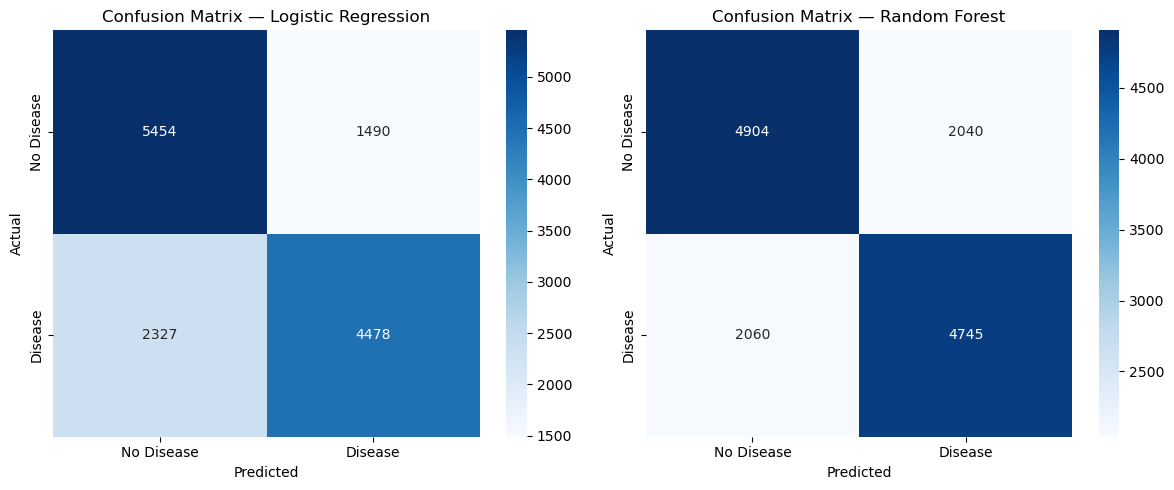

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, Xt, name in [
        (axes[0], lr, X_test_sc, 'Logistic Regression'),
        (axes[1], rf, X_test, 'Random Forest')]:
    cm = confusion_matrix(y_test, model.predict(Xt))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease','Disease'],
                yticklabels=['No Disease','Disease'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/confusion_matrix.png', dpi=120)
plt.show()

## ⚖️ Overfitting Check (Train vs Test Accuracy)

In [8]:
for model, Xtr, Xte, name in [
        (lr, X_sc, X_test_sc, 'Logistic Regression'),
        (rf, X_train, X_test, 'Random Forest')]:
    train_acc = accuracy_score(y_train, model.predict(Xtr))
    test_acc  = accuracy_score(y_test,  model.predict(Xte))
    diff = train_acc - test_acc
    print(f'{name}:')
    print(f'  Train Accuracy: {train_acc:.4f}')
    print(f'  Test  Accuracy: {test_acc:.4f}')
    print(f'  Difference    : {diff:.4f} — {"OK" if diff < 0.05 else "Possible Overfit"}')
    print()

Logistic Regression:
  Train Accuracy: 0.7284
  Test  Accuracy: 0.7224
  Difference    : 0.0060 — OK

Random Forest:
  Train Accuracy: 0.9760
  Test  Accuracy: 0.7018
  Difference    : 0.2742 — Possible Overfit



## 💾 Save Metrics

In [10]:
os.makedirs('../outputs', exist_ok=True)
with open('../outputs/metrics.txt', 'w') as f:
    for model, Xt, name in [
            (lr, X_test_sc, 'Logistic Regression'),
            (rf, X_test, 'Random Forest')]:
        y_pred = model.predict(Xt)
        f.write(f'=== {name} ===\n')
        f.write(f'  accuracy : {accuracy_score(y_test, y_pred):.4f}\n')
        f.write(f'  precision: {precision_score(y_test, y_pred):.4f}\n')
        f.write(f'  recall   : {recall_score(y_test, y_pred):.4f}\n')
        f.write(f'  f1       : {f1_score(y_test, y_pred):.4f}\n\n')
print('Metrics saved to ../outputs/metrics.txt')

Metrics saved to ../outputs/metrics.txt
